In [1]:
# https://huggingface.co/learn/diffusion-course/en/unit4/3

import torch, random
import numpy as np
import torch.nn.functional as F
from tqdm.auto import tqdm
from IPython.display import Audio
from matplotlib import pyplot as plt
from diffusers import DiffusionPipeline
# from diffusers import AudioLDM2Pipeline
from torchaudio import transforms as AT
from torchvision import transforms as IT

/home/carl/.virtualenvs/stable-diffusion-tutorial/lib/python3.10/site-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/home/carl/.virtualenvs/stable-diffusion-tutorial/lib/python3.10/site-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


In [2]:
# Load a pre-trained audio diffusion pipeline
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
pipe = DiffusionPipeline.from_pretrained("teticio/audio-diffusion-instrumental-hiphop-256").to(device)
# pipe = AudioLDM2Pipeline.from_pretrained("teticio/audio-diffusion-instrumental-hiphop-256").to(device)

/home/carl/.virtualenvs/stable-diffusion-tutorial/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
unet/diffusion_pytorch_model.safetensors not found


Loading pipeline components...:   0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

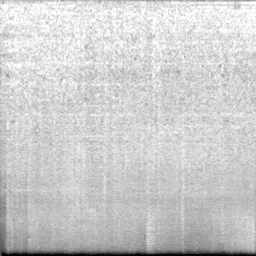

In [4]:
# Sample from the pipeline and display the outputs
output = pipe()
display(output.images[0])
display(Audio(output.audios[0], rate=pipe.mel.get_sample_rate()))

In [5]:
# The audio array
output.audios[0].shape

(1, 130560)

In [6]:
# The output image (spectrogram)
output.images[0].size

(256, 256)

In [7]:
pipe.mel

Mel {
  "_class_name": "Mel",
  "_diffusers_version": "0.24.0",
  "hop_length": 512,
  "n_fft": 2048,
  "n_iter": 32,
  "sample_rate": 22050,
  "top_db": 80,
  "x_res": 256,
  "y_res": 256
}

tensor(8.8818e-16) tensor(6.4483)


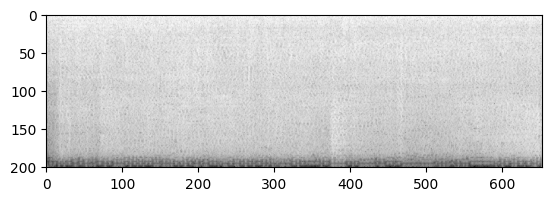

In [8]:
# Calculate and show a spectrogram for our generated audio sample using torchaudio
spec_transform = AT.Spectrogram(power=2)
spectrogram = spec_transform(torch.tensor(output.audios[0]))
print(spectrogram.min(), spectrogram.max())
log_spectrogram = spectrogram.log()
plt.imshow(log_spectrogram[0], cmap='gray');